# **Data Preparation**

In [4]:
!pip install tensorflow optuna --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.4/267.4 kB 29.3 MB/s eta 0:00:00


In [5]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats

import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LSTM, Input
from tensorflow.keras.optimizers import Adam


In [1]:
!git clone https://github.com/maiht0101/regime-aware-volatility-forecasting.git

Cloning into 'regime-aware-volatility-forecasting'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (25/25), done.
remote: Total 38 (delta 6), reused 15 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 1.01 MiB | 17.87 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
%cd regime-aware-volatility-forecasting

/content/regime-aware-volatility-forecasting


In [6]:
# Load data
ndx = pd.read_pickle('data/processed/ndx.pkl')
ndx.head()

,Close,High,Low,Open,Volume,Returns,YZ_Vol,log_vol_1d,log_vol_5d,log_vol_22d,vxn_log,parkinson_vol_log,ema_5,ema_22,vol_5,vol_22
Date,,,,,,,,,,,,,,,,
2000-01-04,3546.199951,3766.570068,3542.729980,3766.570068,1511840000,-6.663455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,3507.310059,3576.169922,3371.750000,3543.129883,1735670000,-1.102722,NaN,NaN,NaN,NaN,NaN,-3.302402,NaN,NaN,NaN,NaN
2000-01-06,3340.810059,3513.550049,3334.020020,3488.310059,1598320000,-4.863607,NaN,NaN,NaN,NaN,NaN,-3.342476,NaN,NaN,NaN,NaN
2000-01-07,3529.600098,3529.750000,3314.750000,3337.260010,1634930000,5.497127,NaN,NaN,NaN,NaN,NaN,-3.457821,NaN,NaN,NaN,NaN
2000-01-10,3717.409912,3756.169922,3558.209961,3558.209961,1691710000,5.184259,NaN,NaN,NaN,NaN,NaN,-3.276977,NaN,NaN,NaN,NaN


In [7]:
ndx.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6537 entries, 2000-01-04 to 2025-12-30
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Close              6537 non-null   float64
 1   High               6537 non-null   float64
 2   Low                6537 non-null   float64
 3   Open               6537 non-null   float64
 4   Volume             6537 non-null   int64  
 5   Returns            6537 non-null   float64
 6   YZ_Vol             6515 non-null   float64
 7   log_vol_1d         6514 non-null   float64
 8   log_vol_5d         6510 non-null   float64
 9   log_vol_22d        6493 non-null   float64
 10  vxn_log            6271 non-null   float64
 11  parkinson_vol_log  6536 non-null   float64
 12  ema_5              6514 non-null   float64
 13  ema_22             6514 non-null   float64
 14  vol_5              6532 non-null   float64
 15  vol_22             6515 non-null   float64
dtypes: flo

# **Predictive Variables on Train**

In [8]:
# Dataframe for lstm data
data = ndx[['YZ_Vol']].copy()

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6537 entries, 2000-01-04 to 2025-12-30
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   YZ_Vol  6515 non-null   float64
dtypes: float64(1)
memory usage: 102.1 KB


In [10]:
# drop nan values
data.dropna(inplace=True)

In [11]:
# Split to train and test
split = int(len(ndx[['Returns']]) * 0.9)

train = data[:split]
test = data[split:]

## **Train Set**

In [12]:
# adding predictive variables
# lag of RV
train = train.copy()
log_vol = np.log(train['YZ_Vol'])
train['log_vol_1d'] = log_vol.shift(1)
train['log_vol_5d'] = log_vol.rolling(5).mean().shift(1)
train['log_vol_22d'] = log_vol.rolling(22).mean().shift(1)

In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5883 entries, 2000-02-04 to 2023-06-23
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YZ_Vol       5883 non-null   float64
 1   log_vol_1d   5882 non-null   float64
 2   log_vol_5d   5878 non-null   float64
 3   log_vol_22d  5861 non-null   float64
dtypes: float64(4)
memory usage: 229.8 KB


In [14]:
# keep only non-null values
train = train.dropna()
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5861 entries, 2000-03-08 to 2023-06-23
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YZ_Vol       5861 non-null   float64
 1   log_vol_1d   5861 non-null   float64
 2   log_vol_5d   5861 non-null   float64
 3   log_vol_22d  5861 non-null   float64
dtypes: float64(4)
memory usage: 228.9 KB


In [16]:
# define X_train and y_train
y_train = train['YZ_Vol'].copy()
X_train = train.drop(['YZ_Vol'], axis=1).copy()

In [17]:
y_train.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 5861 entries, 2000-03-08 to 2023-06-23
Series name: YZ_Vol
Non-Null Count  Dtype  
--------------  -----  
5861 non-null   float64
dtypes: float64(1)
memory usage: 91.6 KB


In [18]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5861 entries, 2000-03-08 to 2023-06-23
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_vol_1d   5861 non-null   float64
 1   log_vol_5d   5861 non-null   float64
 2   log_vol_22d  5861 non-null   float64
dtypes: float64(3)
memory usage: 183.2 KB


array([[<Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>],
       [<Axes: xlabel='Date'>]], dtype=object)

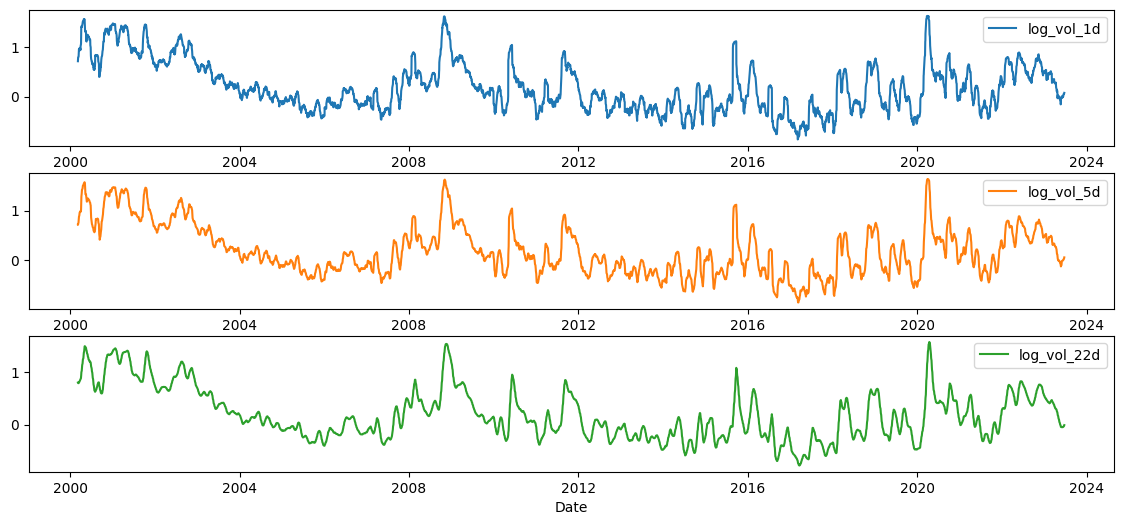

In [19]:
# plot X_train
X_train.plot(
    subplots=True,
    layout=(3, int(np.ceil(len(X_train.columns)/3))),
    figsize=(14, 6),
    sharex=False
)

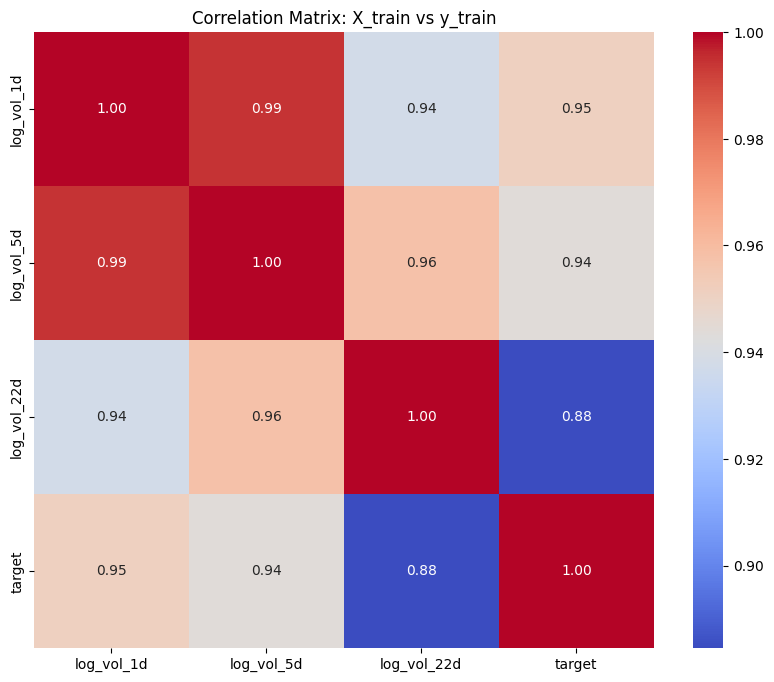

In [20]:
df_corr = pd.concat([X_train, y_train.rename("target")], axis=1)

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: X_train vs y_train")
plt.savefig("correlation_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

In [21]:
# delete log_vol_5d
X_train = X_train.drop(['log_vol_5d'], axis=1)
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5861 entries, 2000-03-08 to 2023-06-23
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_vol_1d   5861 non-null   float64
 1   log_vol_22d  5861 non-null   float64
dtypes: float64(2)
memory usage: 137.4 KB


In [22]:
# define the list of features to scale
features_to_scale = X_train.columns

# **Train LSTM**

In [32]:
def create_sequences(features, targets, seq_length):
    features_arr = np.asarray(features)
    targets_arr = np.asarray(targets)

    # Number of sliding sequences we can create
    num_sequences = len(features_arr) - seq_length

    # Generate X using NumPy stride tricks
    shape = (num_sequences, seq_length, features_arr.shape[1])
    strides = (features_arr.strides[0], features_arr.strides[0], features_arr.strides[1])
    X = np.lib.stride_tricks.as_strided(features_arr, shape=shape, strides=strides)

    # Generate y directly aligned to the end of each sequence
    y = targets_arr[seq_length:]

    return X, y

In [ ]:
# Define walk-forward splits
def generate_walk_forward_splits(total_size, initial_train_size, val_size, step_size):
    splits = []

    start = 0
    while start + initial_train_size + val_size <= total_size:
        train_start = start
        train_end = start + initial_train_size
        val_end = train_end + val_size

        splits.append((train_start, train_end, train_end, val_end))
        start += step_size

    return splits

In [ ]:
# ROLLING WINDOW HYPERPARAMETER TUNING
def build_lstm(hp_dict, input_shape):
    # Determine the number of layers (defaults to 2 if not provided for backwards compatibility)
    num_layers = hp_dict.get('num_layers', 2)

    model = Sequential()
    model.add(Input(shape=input_shape))

    if num_layers == 1:
        # 1-Layer LSTM setup
        model.add(LSTM(units=hp_dict['units'], return_sequences=False))
        model.add(Dropout(hp_dict['dropout']))
    else:
        # 2-Layer LSTM setup
        model.add(LSTM(units=hp_dict['units'], return_sequences=True))
        model.add(Dropout(hp_dict['dropout']))
        model.add(LSTM(units=hp_dict['units'], return_sequences=False))
        model.add(Dropout(hp_dict['dropout']))

    # Output layer
    model.add(Dense(1))

    model.compile(
        optimizer=Adam(learning_rate=hp_dict['lr']),
        loss='mae'
    )
    return model

In [ ]:
def objective(trial):

    # Hyperparameter Search Space
    hp_dict = {
    # Sequence & Architecture Dynamics
    'num_layers': trial.suggest_categorical('num_layers', [1, 2]),
    'units': trial.suggest_categorical('units', [32, 64, 128, 256]),

    # Regularization
    'dropout': trial.suggest_categorical('dropout', [0.1, 0.2, 0.3, 0.4]),
    'recurrent_dropout': trial.suggest_categorical('recurrent_dropout', [0.0, 0.1, 0.2]),

    # Optimization
    'lr': trial.suggest_categorical('lr', [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2]) }

    print(f"Parameters selected: {hp_dict}")

    splits = generate_walk_forward_splits(
        total_size=len(X_train),
        initial_train_size=initial_train_size,
        val_size=val_size,
        step_size=step_size
    )

    fold_losses = []

    for fold, (train_start, train_end, val_start, val_end) in enumerate(splits):
        print(f"  → Processing Fold {fold + 1}/{len(splits)}...", end="", flush=True)

        # Prevent data leakage: Split raw frames first using global X_train
        df_train = X_train.iloc[train_start:train_end].copy()
        df_val = X_train.iloc[val_start:val_end].copy()

        # Fresh scalers per fold
        scaler_std = StandardScaler()

        # Fit ONLY on training fold, transform both
        df_train[features_to_scale] = scaler_std.fit_transform(df_train[features_to_scale])
        df_val[features_to_scale] = scaler_std.transform(df_val[features_to_scale])

        # Consolidate features
        X_train_raw = df_train[features_to_scale].values
        y_train_raw = y_train.iloc[train_start:train_end].values
        X_val_raw = df_val[features_to_scale].values
        y_val_raw = y_train.iloc[val_start:val_end].values

        # Fast sequence generation
        X_train_seq, y_train_seq = create_sequences(X_train_raw, y_train_raw, lookback)
        X_val_seq, y_val_seq = create_sequences(X_val_raw, y_val_raw, lookback)

        if len(X_train_seq) == 0 or len(X_val_seq) == 0:
            continue

        # Build and fit LSTM
        input_shape = (lookback, X_train_seq.shape[2])
        model = build_lstm(hp_dict, input_shape)

        early_stop = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )

        model.fit(
            X_train_seq, y_train_seq,
            validation_data=(X_val_seq, y_val_seq),
            epochs=10,
            batch_size=64,
            verbose=0,
            callbacks=[early_stop]
        )

        val_loss = model.evaluate(X_val_seq, y_val_seq, verbose=0)
        fold_losses.append(val_loss)

        print(f" Done. Val MAE: {val_loss:.4f}")

        trial.report(val_loss, step=fold)
        if trial.should_prune():
            print(f"Trial #{trial.number} pruned early at fold {fold + 1} due to poor performance.")
            tf.keras.backend.clear_session()
            raise optuna.TrialPruned()

    tf.keras.backend.clear_session()

    mean_loss = np.mean(fold_losses) if fold_losses else float('inf')
    print(f"Trial #{trial.number} Finished. Average Cross-Val MAE: {mean_loss:.4f}")

    return mean_loss

In [ ]:
if __name__ == "__main__":
    # Global Parameters Configuration
    lookback = 22
    initial_train_size = 1500
    val_size = 126
    step_size = 126

    # Initialize optimization study with a Median Pruner
    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5)
    )

    # Run tuning
    study.optimize(objective, n_trials=15)

    print("\n--- TUNING COMPLETE ---")
    print("Best Trial Hyperparameters:", study.best_trial.params)
    print("Best Cross-Validated MAE:", study.best_value)

[I 2026-08-22 16:28:52,499] A new study created in memory with name: no-name-9234b83b-6efe-4031-b75c-7dd07b53bfd2


Parameters selected: {'num_layers': 1, 'units': 128, 'dropout': 0.1, 'recurrent_dropout': 0.1, 'lr': 0.05}
  → Processing Fold 1/34...

I0000 00:00:1787416134.125641      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787416134.131623      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


 Done. Val MAE: 0.0513
  → Processing Fold 2/34... Done. Val MAE: 0.0300
  → Processing Fold 3/34... Done. Val MAE: 0.0430
  → Processing Fold 4/34... Done. Val MAE: 0.1157
  → Processing Fold 5/34... Done. Val MAE: 0.0424
  → Processing Fold 6/34... Done. Val MAE: 0.5547
  → Processing Fold 7/34... Done. Val MAE: 0.0299
  → Processing Fold 8/34... Done. Val MAE: 0.0369
  → Processing Fold 9/34... Done. Val MAE: 0.0864
  → Processing Fold 10/34... Done. Val MAE: 0.0535
  → Processing Fold 11/34... Done. Val MAE: 0.0490
  → Processing Fold 12/34... Done. Val MAE: 0.0753
  → Processing Fold 13/34... Done. Val MAE: 0.0876
  → Processing Fold 14/34... Done. Val MAE: 0.0297
  → Processing Fold 15/34... Done. Val MAE: 0.0309
  → Processing Fold 16/34... Done. Val MAE: 0.0407
  → Processing Fold 17/34... Done. Val MAE: 0.0352
  → Processing Fold 18/34... Done. Val MAE: 0.0913
  → Processing Fold 19/34... Done. Val MAE: 0.0653
  → Processing Fold 20/34... Done. Val MAE: 0.0572
  → Processing F

[I 2026-08-22 16:31:02,591] Trial 0 finished with value: 0.0740320037721711 and parameters: {'num_layers': 1, 'units': 128, 'dropout': 0.1, 'recurrent_dropout': 0.1, 'lr': 0.05}. Best is trial 0 with value: 0.0740320037721711.


...

Trial #12 Finished. Average Cross-Val MAE: 0.0649
Parameters selected: {'num_layers': 1, 'units': 64, 'dropout': 0.4, 'recurrent_dropout': 0.0, 'lr': 0.01}
  → Processing Fold 1/34... Done. Val MAE: 0.0341
  → Processing Fold 2/34... Done. Val MAE: 0.0243
  → Processing Fold 3/34... Done. Val MAE: 0.0413
  → Processing Fold 4/34... Done. Val MAE: 0.0921
  → Processing Fold 5/34... Done. Val MAE: 0.0360
  → Processing Fold 6/34... Done. Val MAE: 0.2752
  → Processing Fold 7/34... Done. Val MAE: 0.0359
  → Processing Fold 8/34... Done. Val MAE: 0.0346
  → Processing Fold 9/34... Done. Val MAE: 0.1232
  → Processing Fold 10/34... Done. Val MAE: 0.0394
  → Processing Fold 11/34... Done. Val MAE: 0.0627
  → Processing Fold 12/34... Done. Val MAE: 0.0416
  → Processing Fold 13/34... Done. Val MAE: 0.0269
  → Processing Fold 14/34... Done. Val MAE: 0.0304
  → Processing Fold 15/34... Done. Val MAE: 0.0298
  → Processing Fold 16/34... Done. Val MAE: 0.0284
  → Processing Fold 17/34... Done. Va

[I 2026-08-22 17:00:44,344] Trial 13 finished with value: 0.05805139205254176 and parameters: {'num_layers': 1, 'units': 64, 'dropout': 0.4, 'recurrent_dropout': 0.0, 'lr': 0.01}. Best is trial 2 with value: 0.057450971949626416.


Trial #13 Finished. Average Cross-Val MAE: 0.0581
Parameters selected: {'num_layers': 1, 'units': 64, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.01}
  → Processing Fold 1/34... Done. Val MAE: 0.0282
  → Processing Fold 2/34... Done. Val MAE: 0.0235
  → Processing Fold 3/34... Done. Val MAE: 0.0461
  → Processing Fold 4/34... Done. Val MAE: 0.0816
  → Processing Fold 5/34... Done. Val MAE: 0.0319
  → Processing Fold 6/34... Done. Val MAE: 0.3454
  → Processing Fold 7/34... Done. Val MAE: 0.0339
  → Processing Fold 8/34... Done. Val MAE: 0.0297
  → Processing Fold 9/34... Done. Val MAE: 0.1058
  → Processing Fold 10/34... Done. Val MAE: 0.0323
  → Processing Fold 11/34... Done. Val MAE: 0.0635
  → Processing Fold 12/34... Done. Val MAE: 0.0447
  → Processing Fold 13/34... Done. Val MAE: 0.0269
  → Processing Fold 14/34... Done. Val MAE: 0.0293
  → Processing Fold 15/34... Done. Val MAE: 0.0330
  → Processing Fold 16/34... Done. Val MAE: 0.0274
  → Processing Fold 17/34... Done. Va

[I 2026-08-22 17:02:51,787] Trial 14 finished with value: 0.057442005504580104 and parameters: {'num_layers': 1, 'units': 64, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.01}. Best is trial 14 with value: 0.057442005504580104.


Trial #14 Finished. Average Cross-Val MAE: 0.0574

--- TUNING COMPLETE ---
Best Trial Hyperparameters: {'num_layers': 1, 'units': 64, 'dropout': 0.2, 'recurrent_dropout': 0.2, 'lr': 0.01}
Best Cross-Validated MAE: 0.057442005504580104


# **Refit on train set**

In [29]:
# FIT FINAL GLOBAL SCALERS ON TRAIN DATA ONLY
# Scale features
vol_scaler_std = StandardScaler()

# Map and FIT on the final train block
X_final_train_scaled  = vol_scaler_std.fit_transform(X_train[features_to_scale])


In [ ]:
# FORMAT INTO 3D TENSORS (SAMPLES, TIME STEPS, FEATURES)
lookback = 22

X_train_final, y_train_final = create_sequences(X_final_train_scaled, y_train, lookback)

print(f"Final Production Training Shapes:")
print(f"Features (X): {X_train_final.shape}")
print(f"Targets  (y): {y_train_final.shape}")

Final Production Training Shapes:
Features (X): (5840, 22, 2)
Targets  (y): (5840,)


In [ ]:
# INSTANTIATE & TRAIN THE CHOSEN PRODUCTION MODEL
best_hps = study.best_trial.params

input_shape = (lookback, X_train_final.shape[2])
final_model = build_lstm(best_hps, input_shape)

early_stop_final = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=7,
    restore_best_weights=True
)

print("\nTraining production model on full historical training data...")
# We train for slightly more epochs since we are utilizing more data at once
final_model.fit(
    X_train_final,
    y_train_final,
    epochs=50,
    batch_size=64,
    callbacks=[early_stop_final],
    shuffle=False,
    verbose=1
)

print("\nStep 1 Complete! The production model is fully optimized and trained.")


Training production model on full historical training data...
Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.4676
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2240
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1926
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1839
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1612
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1365
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1155
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1057
Epoch 9/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1007
Epoch 10/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0966
Epoch 11/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1025
Epoch 12/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0954
Epoch 13/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0994
Epoch 14/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0959
Epoch 15/50
92/92 ━━━━

In [ ]:
final_model.save("/kaggle/working/final_lstm.keras")

# **Predictive Variables on Test**

In [23]:
# adding predictive variables
# lag of RV
test = test.copy()
log_vol_test = np.log(test['YZ_Vol'])
test['log_vol_1d'] = log_vol_test.shift(1)
test['log_vol_22d'] = log_vol_test.rolling(22).mean().shift(1)

In [24]:
test = test.dropna()
test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 610 entries, 2023-07-27 to 2025-12-30
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   YZ_Vol       610 non-null    float64
 1   log_vol_1d   610 non-null    float64
 2   log_vol_22d  610 non-null    float64
dtypes: float64(3)
memory usage: 19.1 KB


In [25]:
# define X_train and y_train
y_test = test['YZ_Vol'].copy()
X_test = test.drop(['YZ_Vol'], axis=1).copy()

In [26]:
y_test.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 610 entries, 2023-07-27 to 2025-12-30
Series name: YZ_Vol
Non-Null Count  Dtype  
--------------  -----  
610 non-null    float64
dtypes: float64(1)
memory usage: 9.5 KB


In [27]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 610 entries, 2023-07-27 to 2025-12-30
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_vol_1d   610 non-null    float64
 1   log_vol_22d  610 non-null    float64
dtypes: float64(2)
memory usage: 14.3 KB


# **Out-of-sample Predictions**

In [30]:
# SCALE THE RAW TEST SET FEATURES
X_final_test_scaled = vol_scaler_std.transform(X_test[features_to_scale])


In [35]:
# FORMAT TEST FEATURES AND TARGETS INTO 3D SEQUENCES
X_test_final, y_test_final = create_sequences(X_final_test_scaled, y_test, lookback)

print(f"Final Out-of-Sample Test Shapes:")
print(f"Features (X): {X_test_final.shape}")
print(f"Targets  (y): {y_test_final.shape}")

Final Out-of-Sample Test Shapes:
Features (X): (588, 22, 2)
Targets  (y): (588,)


In [ ]:
# GENERATE OUT-OF-SAMPLE PREDICTIONS
print("\nGenerating out-of-sample predictions from the production model...")

# Predict the expected returns for tomorrow
final_predictions = final_model.predict(X_test_final)

# Flatten the predictions array for easier analysis later
final_predictions = final_predictions.flatten()

print(f"Step 2 Complete! Generated {len(final_predictions)} out-of-sample directional return forecasts.")
print(f"Sample Predictions (first 5): {final_predictions[:5]}")


Generating out-of-sample predictions from the production model...
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Step 2 Complete! Generated 588 out-of-sample directional return forecasts.
Sample Predictions (first 5): [1.0360622  1.069293   0.99313366 0.96314454 0.9706648 ]


# **Evaluation Metrics**

In [ ]:
# Evaluation metrics definitiion

# QLIKE
def qlike(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Safety: Avoid non-positive values that break np.log
    eps = 1e-9
    y_pred = np.maximum(y_pred, eps)
    y_true = np.maximum(y_true, eps)

    # Calculation: Log(Pred) + (True / Pred)
    # This works for both scalars and vectors
    loss = np.log(y_pred) + (y_true / y_pred)

    # Aggregation: Return the mean of the losses
    return np.mean(loss)

In [ ]:
# Get the dates belonging strictly to your test set
test_dates = data.index[split:]

# Slice the index from the tail end to match the exact length of your predictions
num_predictions = len(final_predictions)
prediction_dates = test_dates[-num_predictions:]

# Create a clean Pandas Series with the true index
df_predictions = pd.Series(
    data=final_predictions,
    index=prediction_dates,
    name="predicted_volatility"
)

# Combine everything into a clean comparison DataFrame
df_comparison = pd.DataFrame({
    "Actual Volatility": y_test_final,
    "Predicted Volatility": final_predictions
}, index=prediction_dates)

print(df_comparison.head())
print("-" * 35)
print(f"Total rows successfully matched: {len(df_comparison)}")

            Actual Volatility  Predicted Volatility
Date                                               
2023-08-28           1.005086              1.036062
2023-08-29           0.997276              1.069293
2023-08-30           1.000292              0.993134
2023-08-31           0.997463              0.963145
2023-09-01           0.974569              0.970665
-----------------------------------
Total rows successfully matched: 588


In [ ]:
print(df_comparison.head())
print(df_comparison.describe())

            Actual Volatility  Predicted Volatility
Date                                               
2023-08-28           1.005086              1.036062
2023-08-29           0.997276              1.069293
2023-08-30           1.000292              0.993134
2023-08-31           0.997463              0.963145
2023-09-01           0.974569              0.970665
       Actual Volatility  Predicted Volatility
count         588.000000            588.000000
mean            1.144774              1.138700
std             0.479039              0.512485
min             0.595275              0.562859
25%             0.859180              0.847911
50%             1.005684              0.995040
75%             1.238567              1.216952
max             3.155370              3.360363


In [ ]:
y_test_pred = final_predictions
test_metrics = {
    "RMSE": np.sqrt(mean_squared_error(y_test_final, y_test_pred)),
    "MAE": mean_absolute_error(y_test_final, y_test_pred),
    "Qlike": qlike(y_test_final, y_test_pred)
}

test_metrics = pd.DataFrame(test_metrics, index=["Test"])
print(test_metrics.round(4))

        RMSE     MAE   Qlike
Test  0.0994  0.0569  1.0754


In [ ]:
# Make predictions on train set
y_train_pred = final_model.predict(X_train_final)

183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
train_metrics = {
    "RMSE": np.sqrt(mean_squared_error(y_train_final, y_train_pred)),
    "MAE": mean_absolute_error(y_train_final, y_train_pred),
    "Qlike": qlike(y_train_final, y_train_pred)
}

train_metrics = pd.DataFrame(train_metrics, index=["Train"])
print(train_metrics.round(4))

         RMSE    MAE   Qlike
Train  0.1026  0.056  1.4837


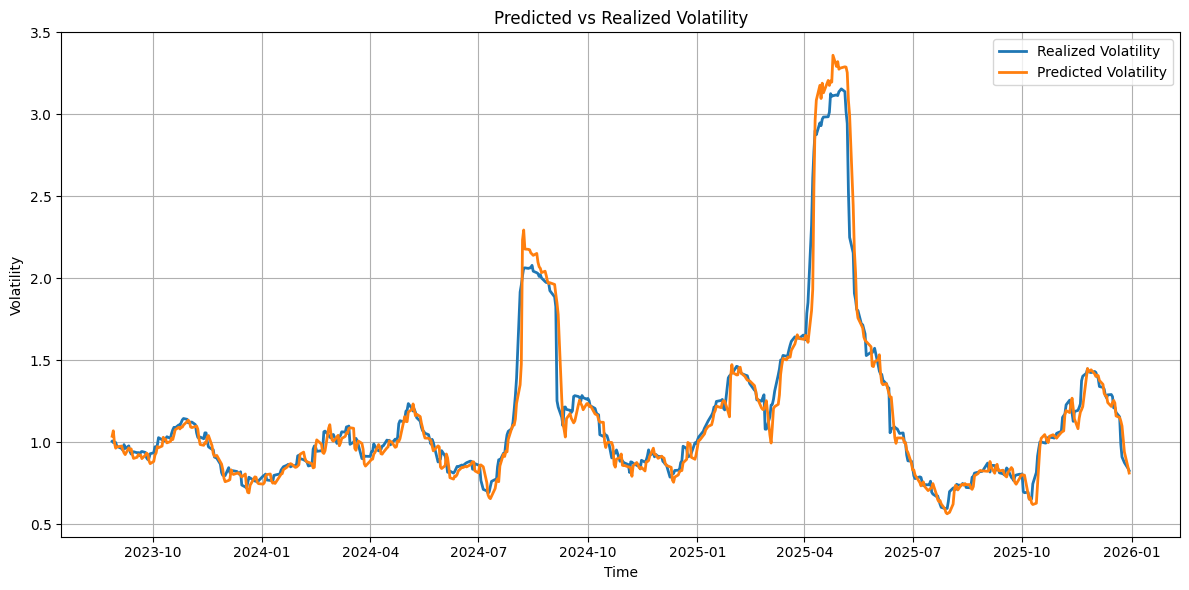

In [ ]:
plt.figure(figsize=(12, 6))

plt.plot(df_comparison.index, df_comparison['Actual Volatility'], label='Realized Volatility', linewidth=2)
plt.plot(df_comparison.index, df_comparison['Predicted Volatility'], label='Predicted Volatility', linewidth=2)

plt.title('Predicted vs Realized Volatility')
plt.xlabel('Time')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
import pickle

df_comparison.to_pickle("/kaggle/working/lstm_predict.pkl")